# Bank Data Analysis

# Objective

In this case study, you will be working on Banking Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to give you hands-on experience in analyzing large-scale banking datasets using PySpark and AWS services. You will apply techniques learned in data analytics to clean, transform, and explore banking data, drawing meaningful insights to support financial decision-making. Apart from understanding how big data tools can optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing market capitalization trends, currency conversions, and global banking performance. Additionally, you will use AWS S3 to store the processed data once the ETL pipeline is complete, ensuring efficient data management and retrieval.


# Business Value

The banking industry operates in a highly competitive and globalized market where financial institutions must continuously monitor their market position, performance, and currency fluctuations. To stay competitive, banks must leverage data-driven insights to optimize their financial strategies, assess market trends, and make informed decisions. In this assignment, you will analyze banking data to uncover patterns in market capitalization, currency conversions, and global rankings. With Apache Spark's ability to handle large datasets efficiently, financial institutions can process vast amounts of data in real-time, helping them make faster and more informed decisions.


As an analyst at a financial institution, your task is to examine historical banking data to derive actionable insights that can drive strategic growth. Your analysis will help identify the top 10 largest banks by market capitalization, convert market cap values into multiple currencies (USD, GBP, EUR, INR), and store the processed data for easy retrieval. To enhance scalability and accessibility, you will utilize AWS S3 for data storage, ensuring seamless integration with cloud-based analytics tools. By leveraging big data analytics and cloud services, financial institutions can streamline operations, enhance decision-making, and maximize revenue opportunities.


# Dataset

The data for this project can be accessed from the following [wikipedia link](https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks).

The dataset used in this analysis comprises global banking data extracted from a Wikipedia page (List of Largest Banks) archived as of September 2023.

It includes rankings of the world's largest banks based on market capitalization (in USD billions) and is structured into a single table with three columns. The data was scraped programmatically, cleaned, and transformed using PySpark to support cross-currency analysis. Exchange rate data (for USD, GBP, EUR, and INR) was sourced from a CSV file to enable currency conversions. The processed dataset is stored in CSV and SQLite formats for accessibility and efficient querying.

The dataset consists of a single table (Largest_banks) with the following three key attributes:
- **Rank:** Numerical position of the bank based on market capitalization.
- **Bank Name:** Name of the financial institution.
- **Market Cap (USD Billion):** Market valuation of the bank in USD billions.
This dataset enables analysis of global banking trends, cross-currency valuations, and the relative market dominance of financial institutions.

An additional data on market exchange rates is available to compare the marketcap dealing with different currencies.


<h2>Assignment Tasks</h2>

<ol>
    <li>
        <strong>Data Preparation</strong>
        <p>The dataset consists of a structured table containing global banking data. Before performing any analysis, it is crucial to prepare the data to ensure consistency and efficiency in processing.</p>
        Check for data consistency and ensure all columns are correctly formatted.<br>
        Structure and prepare the data for further processing and analysis.<br>
</br>
    <li>
        <strong>Data Cleaning</strong>
        <ul>
            2.1. <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.<br>
            2.2. <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.<br>
            2.3. <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.<br>
        </ul>
</br>
    <li>
        <strong>Exploratory Data Analysis:</strong></br>
            EDA Finding Patterns - Analyze the dataset and find patterns based on the following points:
                <ul>
                    3.1. Convert PySpark DataFrame to Pandas DataFrame for visualization.<br>
                    3.2. Analyze the distribution of market capitalization using a histogram.<br>
                    3.3. Identify the top 10 banks by market capitalization using a bar chart.<br>
                    3.4. Visualize the relationship between market capitalization and bank ranking using a scatter plot.<br>
                    3.5. Use a boxplot to examine the spread and outliers in market capitalization.<br>
                    3.6. Display the quartile distribution of market capitalization using a violin plot.<br>
                    3.7. Compute cumulative market share and visualize it with a line plot.<br>
                    3.8. Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.<br>
                    3.9. Calculate and display market share distribution of top 10 banks using a pie chart.<br>
                </ul>
        </ul>
</br>
    <li>
        <strong>Banking Data ETL Querying</strong>
        <ul>
            4.1. Perform Advanced Market Capitalization Analysis with Growth Metrics.<br>
            4.2. Analyze Market Concentration and Categorize Banks Based on Market Share Tiers.<br>
            4.3. Examine Statistical Distribution of Market Capitalization Using Quartile Analysis.<br>
            4.4. Conduct Comparative Size Analysis to Classify Banks by Relative Market Size.<br>
            4.5. Evaluate Market Growth and Identify Gaps Between Consecutive Banks.<br>
            4.6. Assess Market Dominance by Measuring Cumulative Share and Dominance Score.<br>
            4.7. Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges.<br>
            4.8. Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics.<br>
        </ul>
    </br>
    <li>
        <strong>Conclusion</strong></br>
            Provide final insights and recommendations based on the analysis:</br>
            <ul>
            5.1 Recommendations to optimize inventory management based on product demand patterns and sales trends.</br>
            5.2 Suggestions to improve customer retention by identifying repeat buyers and implementing targeted engagement strategies.</br>
            5.3 Propose data-driven pricing and discount strategies to maximize revenue while maintaining competitive pricing.</br>
            5.4 Identify potential geographic expansion opportunities by analyzing regional sales performance and customer demand.</br>
            5.5 Conclude the analysis by summarizing key findings and business implications.<br>
            5.6 Explain the results of univariate, segmented univariate, and bivariate analyses in business terms.<br>
            5.7 Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.<br>
            </ul>
    </br>
    <li>
        <strong>Visualization Integration [Optional]</strong>
        <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
        </ul>
</ol>

Import Required Libraries

In [1]:
# # Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [2]:
import os
os.environ["PYSPARK_PYTHON"] = r"C:\Users\Vandana\anaconda3\envs\spark_env\python.exe"
os.environ["PYSPARK_DRIVER_PYTHON"] = r"C:\Users\Vandana\anaconda3\envs\spark_env\python.exe"

# Optional configuration depending on local environment

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import sys
print(sys.executable)

C:\Users\Vandana\anaconda3\envs\spark_env\python.exe


In [5]:
# Import required libraries
import logging
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
# Import PySpark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round, count, when, isnull

In [6]:
# Initialize Spark session
spark = SparkSession.builder \
    .appName("BankingDataAnalysis") \
    .getOrCreate()

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>


The data for this project can be accessed from the wikipedia link provided above. The page features data regarding global banking data.

Utilise the pandas method to read tables from the html document
and extract the requried data consists of a structured format.

Before performing any analysis, it is crucial to prepare the data to ensure consistency, and efficiency in processing.

In [7]:
!pip install lxml

In [8]:
# Initialize Spark session

# URL of the Wikipedia pageks
url = "https://web.archive.org/web/20230908091635/https://en.wikipedia.org/wiki/List_of_largest_banks#By_total_assets"


# Use pandas to read all HTML tables from the page

tables = pd.read_html(url)
print(len(tables))
# Load the correct table (Table 1)

banks_df = tables[1]
print(banks_df)

# Convert pandas DataFrame to PySpark DataFrame

# Rename columns


# Show the first few rows of the PySpark DataFrame

# Print the schema of the DataFrame

# Configure logging


4
   Rank                                Bank name  Market cap (US$ billion)
0     1                           JPMorgan Chase                    432.92
1     2                          Bank of America                    231.52
2     3  Industrial and Commercial Bank of China                    194.56
3     4               Agricultural Bank of China                    160.68
4     5                                HDFC Bank                    157.91
5     6                              Wells Fargo                    155.87
6     7                        HSBC Holdings PLC                    148.90
7     8                           Morgan Stanley                    140.83
8     9                  China Construction Bank                    139.82
9    10                            Bank of China                    136.81


In [9]:
# Convert pandas DataFrame to PySpark DataFrame
pyspark_df = spark.createDataFrame(banks_df)

# Rename columns
df = pyspark_df.toDF("Rank","Bank_Name","Market_Cap_USD_Billion")

# Show the first few rows of the PySpark DataFrame
df.show(5)

+----+--------------------+----------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|
+----+--------------------+----------------------+
|   1|      JPMorgan Chase|                432.92|
|   2|     Bank of America|                231.52|
|   3|Industrial and Co...|                194.56|
|   4|Agricultural Bank...|                160.68|
|   5|           HDFC Bank|                157.91|
+----+--------------------+----------------------+
only showing top 5 rows



In [10]:
# Print the schema of the DataFrame
df.printSchema()

root
 |-- Rank: long (nullable = true)
 |-- Bank_Name: string (nullable = true)
 |-- Market_Cap_USD_Billion: double (nullable = true)



In [11]:
# Configure logging
spark.sparkContext.setLogLevel("WARN")

Load the data for exchange rates

In [12]:
# Load the exchange rate data
exchange_rate = spark.read.format("csv") \
    .option("header", True) \
    .option("inferSchema", True) \
    .load("exchange_rate(in).csv")

# Show the first few rows of the exchange rate data to verify
exchange_rate.show()

+--------+-----+
|Currency| Rate|
+--------+-----+
|     EUR| 0.93|
|     GBP|  0.8|
|     INR|82.95|
+--------+-----+



In [13]:
### Currency Conversion Transformation
# Market capitalization values are converted from USD to other currencies using exchange rate data.

from pyspark.sql.functions import col

# Extract exchange rates
rates = exchange_rate.collect()

# Create dictionary of exchange rates
rate_dict = {row['Currency']: row['Rate'] for row in rates}

# Convert market cap from USD to other currencies
df = df.withColumn("MarketCap_EUR", col("Market_Cap_USD_Billion") * rate_dict["EUR"])
df = df.withColumn("MarketCap_GBP", col("Market_Cap_USD_Billion") * rate_dict["GBP"])
df = df.withColumn("MarketCap_INR", col("Market_Cap_USD_Billion") * rate_dict["INR"])

# Show results
df.show(5)

+----+--------------------+----------------------+------------------+------------------+------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|
+----+--------------------+----------------------+------------------+------------------+------------------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|
|   3|Industrial and Co...|                194.56|180.94080000000002|155.64800000000002|         16138.752|
|   4|Agricultural Bank...|                160.68|          149.4324|           128.544|         13328.406|
|   5|           HDFC Bank|                157.91|          146.8563|           126.328|        13098.6345|
+----+--------------------+----------------------+------------------+------------------+------------------+
only showing top 5 rows



#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>

##**2.1 Handle Missing Values** <font color = red>[10 marks]</font> <br>


In [14]:
# Print the schema to check data types

exchange_rate.printSchema()

root
 |-- Currency: string (nullable = true)
 |-- Rate: double (nullable = true)



In [15]:
# Check for missing values

from pyspark.sql.functions import sum 

null_values = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

null_values.show()

+----+---------+----------------------+-------------+-------------+-------------+
|Rank|Bank_Name|Market_Cap_USD_Billion|MarketCap_EUR|MarketCap_GBP|MarketCap_INR|
+----+---------+----------------------+-------------+-------------+-------------+
|   0|        0|                     0|            0|            0|            0|
+----+---------+----------------------+-------------+-------------+-------------+



In [16]:
# Drop rows with missing values
def drop_rows_with_nulls(data):
    return data.dropna(how="all") # any removes nan values from the rows where are the records are nan
cleaned_data = drop_rows_with_nulls(df)
cleaned_data.show()
# as we can interpret from the output that we haven't any nan values ,this function is only for understanding purpose 
# so we can further use orignal dataframe i.e "df"

+----+--------------------+----------------------+------------------+------------------+------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|
+----+--------------------+----------------------+------------------+------------------+------------------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|
|   3|Industrial and Co...|                194.56|180.94080000000002|155.64800000000002|         16138.752|
|   4|Agricultural Bank...|                160.68|          149.4324|           128.544|         13328.406|
|   5|           HDFC Bank|                157.91|          146.8563|           126.328|        13098.6345|
|   6|         Wells Fargo|                155.87|          144.9591|124.69600000000001|12929.416500000001|
|   7|   HSBC Holdings PLC| 

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


The Market cap is already in numeric so no conversion needed.

In [17]:
# Count the total number of rows
row_count = df.count()
print(f"Total number of rows are : {row_count}")

# Check if there are duplicates
duplicate_rows = df.groupBy(df.columns).count().filter("count > 1")

print("Duplicate rows found:")
duplicate_rows.show()

num_duplicates = duplicate_rows.count()
print(f"Total number of duplicate rows: {num_duplicates}")

Total number of rows are : 10
Duplicate rows found:
+----+---------+----------------------+-------------+-------------+-------------+-----+
|Rank|Bank_Name|Market_Cap_USD_Billion|MarketCap_EUR|MarketCap_GBP|MarketCap_INR|count|
+----+---------+----------------------+-------------+-------------+-------------+-----+
+----+---------+----------------------+-------------+-------------+-------------+-----+

Total number of duplicate rows: 0


##**2.2 Handle Outliers** <font color = red>[5 marks]</font> <br>


In [18]:
# Write code for outlier analysis
from pyspark.sql.functions import lit
def outliers_analysis(df,col_name):
    # calculate Q1 and Q3
    quartile = df.approxQuantile(col_name, [0.25, 0.75], 0.05)
    q1 = quartile[0]
    q3 = quartile[1]
    # calculate the IQR and bounds
    IQR = q3 - q1
    upper_bound = q3 + 1.5 *IQR
    lower_bound = q1 - 1.5 *IQR
    # we will add a column to identify outliers
    return df.withColumn("is_outlier",when((col(col_name) > upper_bound)| (col(col_name) < lower_bound) ,lit(1))
                  .otherwise(lit(0)))
outliers  = outliers_analysis(df,"Market_Cap_USD_Billion")
outliers.show()

#  we will not consider it as a real outliers because it is the data of 10  banks which has highest Market_Cap_USD_Billion  .

+----+--------------------+----------------------+------------------+------------------+------------------+----------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|is_outlier|
+----+--------------------+----------------------+------------------+------------------+------------------+----------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|         1|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|         0|
|   3|Industrial and Co...|                194.56|180.94080000000002|155.64800000000002|         16138.752|         0|
|   4|Agricultural Bank...|                160.68|          149.4324|           128.544|         13328.406|         0|
|   5|           HDFC Bank|                157.91|          146.8563|           126.328|        13098.6345|         0|
|   6|         Wells Fargo|                155.8

Saving the Cleaned Dataset into a CSV File into the S3 Bucket

--- i have succesfully created the s3 bucket on AWS and saved the cleaned data into a csv file.

In [19]:
# df.toPandas().to_csv("banks_market_cap_cleaned_df.csv", index=False)
# df.write\
#   .option("header", "true")\
#   .csv("s3a://BankingData/BankingDataAnalysis/bank_data_by_marketcap")

#**3. Exploratory Data Analysis** <font color = red>[40 marks]</font> <br>


##**3.1. Conversion from PySpark to Pandas DataFrame** <font color = red>[5 marks]</font> <br>

Convert PySpark DataFrame to Pandas DataFrame for visualization

In [20]:
# Convert PySpark DataFrame to Pandas DataFrame
pandas_df = df.toPandas()
pandas_df.head()

,Rank,Bank_Name,Market_Cap_USD_Billion,MarketCap_EUR,MarketCap_GBP,MarketCap_INR
0,1,JPMorgan Chase,432.92,402.6156,346.336,35910.7140
1,2,Bank of America,231.52,215.3136,185.216,19204.5840
2,3,Industrial and Commercial Bank of China,194.56,180.9408,155.648,16138.7520
3,4,Agricultural Bank of China,160.68,149.4324,128.544,13328.4060
4,5,HDFC Bank,157.91,146.8563,126.328,13098.6345


##**3.2. Market Capitalization** <font color = red>[5 marks]</font> <br>

Analyze the distribution of market capitalization using a histogram

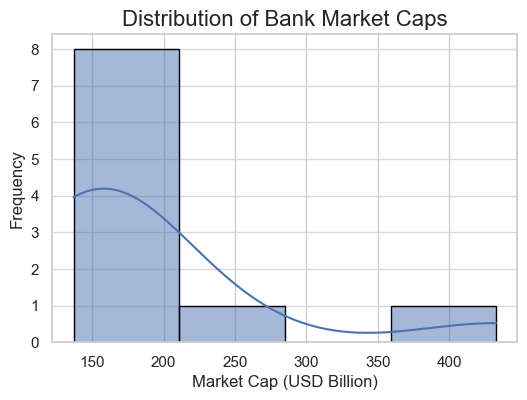

In [21]:
# Distribution of Market Cap (US$ Billion)

# Set the style for seaborn
sns.set_theme(style="whitegrid")
# Plot the distribution of market cap
plt.figure(figsize =(6,4))
sns.histplot(data = pandas_df,x="Market_Cap_USD_Billion",bins=4,kde=True,edgecolor="Black")
plt.title('Distribution of Bank Market Caps', fontsize=16)
plt.xlabel('Market Cap (USD Billion)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75) # Add a grid
plt.show()

##**3.3. Top 10 Banks** <font color = red>[5 Marks]</font> <br>

Identify the top 10 banks by market capitalization using a bar chart

   Rank                                Bank_Name  Market_Cap_USD_Billion  \
0     1                           JPMorgan Chase                  432.92   
1     2                          Bank of America                  231.52   
2     3  Industrial and Commercial Bank of China                  194.56   
3     4               Agricultural Bank of China                  160.68   
4     5                                HDFC Bank                  157.91   
5     6                              Wells Fargo                  155.87   
6     7                        HSBC Holdings PLC                  148.90   
7     8                           Morgan Stanley                  140.83   
8     9                  China Construction Bank                  139.82   
9    10                            Bank of China                  136.81   

   MarketCap_EUR  MarketCap_GBP  MarketCap_INR  
0       402.6156        346.336     35910.7140  
1       215.3136        185.216     19204.5840  
2       180.9408

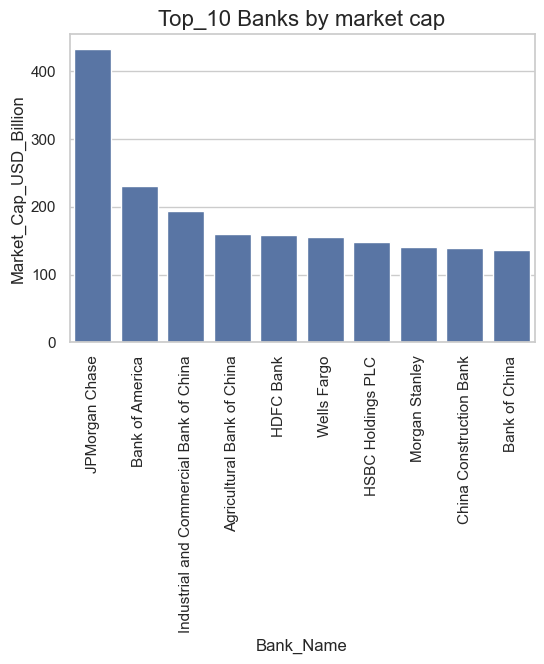

In [22]:
# Top 10 Banks by Market Cap
top10_banks = pandas_df.sort_values(by="Market_Cap_USD_Billion", ascending=False).head(10)

print(top10_banks)
# Sort the DataFrame by market cap in descending order

# Plot the top 10 banks by market cap
plt.figure(figsize=(6,4))
sns.barplot(data=top10_banks,x="Bank_Name",y="Market_Cap_USD_Billion")
plt.title("Top_10 Banks by market cap",fontsize=16)
plt.xticks(rotation=90)
plt.show()

##**3.4. Market Cap vs Bank Ranking** <font color = red>[5 Marks]</font> <br>

Visualize the relationship between market capitalization and bank ranking using a scatter plot

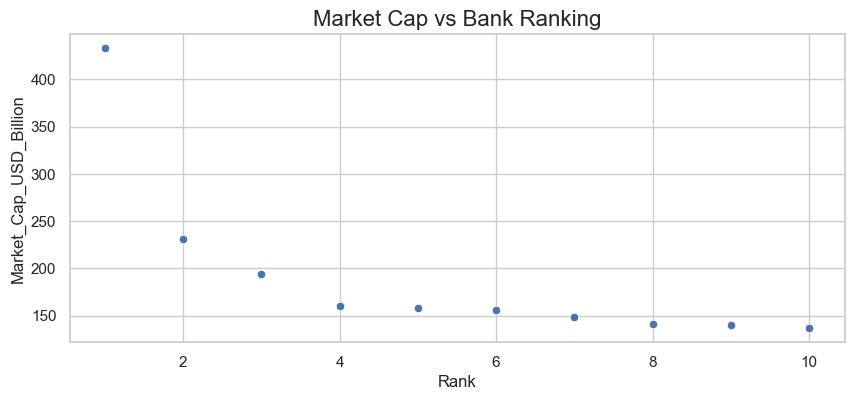

In [23]:
# Market Cap vs Rank

# Plot market cap vs rank
plt.figure(figsize=(10,4))
sns.scatterplot(data=pandas_df,x="Rank",y="Market_Cap_USD_Billion")
plt.title("Market Cap vs Bank Ranking",fontsize=16)
plt.show()

##**3.5. Market Cap Analysis** <font color = red>[5 Marks]</font> <br>

Use a boxplot to examine the spread and outliers in market capitalization.

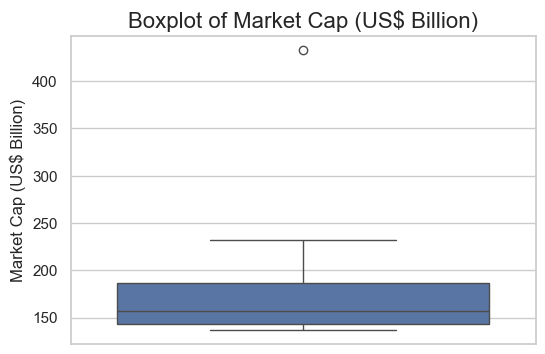

In [24]:
# Boxplot of Market Cap
#To show the spread and outliers in the market capitalization data.

# Plot a boxplot of market cap
plt.figure(figsize=(6,4))
sns.boxplot(data=pandas_df["Market_Cap_USD_Billion"])
plt.title('Boxplot of Market Cap (US$ Billion)', fontsize=16)
plt.ylabel('Market Cap (US$ Billion)', fontsize=12)

plt.show()

##**3.6. Market Cap Quartile Distribution** <font color = red>[5 Marks]</font> <br>

Display the quartile distribution of market capitalization using a violin plot.

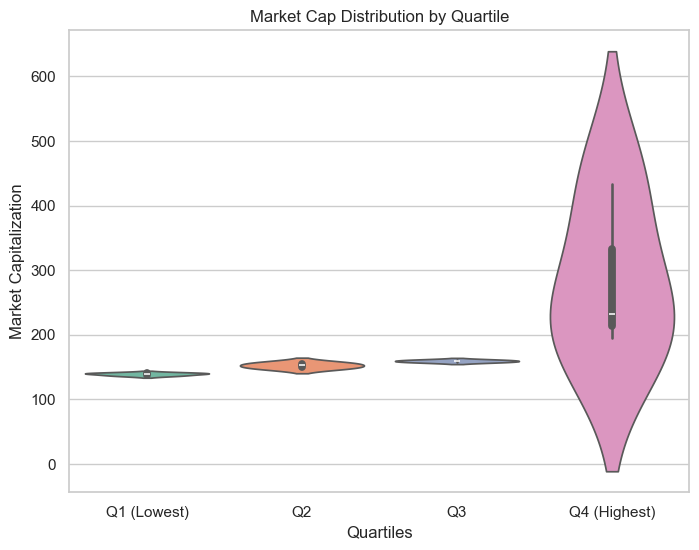

In [25]:
# Market Cap Distribution by Quartile
pandas_df["quartile"]=pd.qcut(pandas_df["Market_Cap_USD_Billion"],q=4,labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"])
pandas_df["quartile"]
# plot graph
plt.figure(figsize=(8,6))
sns.violinplot(x="quartile", y="Market_Cap_USD_Billion", data=pandas_df, inner="box", hue="quartile",palette="Set2")

plt.title("Market Cap Distribution by Quartile")
plt.ylabel("Market Capitalization")
plt.xlabel("Quartiles")
plt.show()

##**3.7. Cumulative Market Share Analysis** <font color = red>[5 Marks]</font> <br>

Compute cumulative market share and visualize it with a line plot.

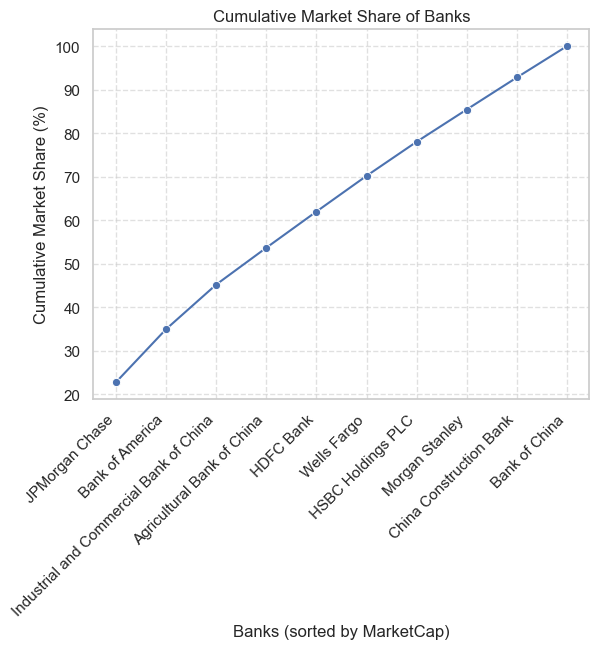

In [26]:
# Cumulative Market Share
pandas_df = pandas_df.sort_values(by="Market_Cap_USD_Billion", ascending=False)
total_market_cap = pandas_df["Market_Cap_USD_Billion"].sum()
pandas_df["market_share"] = pandas_df["Market_Cap_USD_Billion"]/total_market_cap * 100
pandas_df["cum_market_share"] = pandas_df["market_share"].cumsum()

# Plot
sns.lineplot(data=pandas_df,x="Bank_Name",y="cum_market_share",marker="o")
plt.title("Cumulative Market Share of Banks")
plt.xlabel("Banks (sorted by MarketCap)")
plt.ylabel("Cumulative Market Share (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

##**3.8. Categorising Banks** <font color = red>[5 Marks]</font> <br>

Categorize banks into market capitalization ranges and analyze their distribution using a bar chart.

CapCategory
Mid Cap (100–200B)      8
Large Cap (200–300B)    1
Mega Cap (>300B)        1
Name: count, dtype: int64


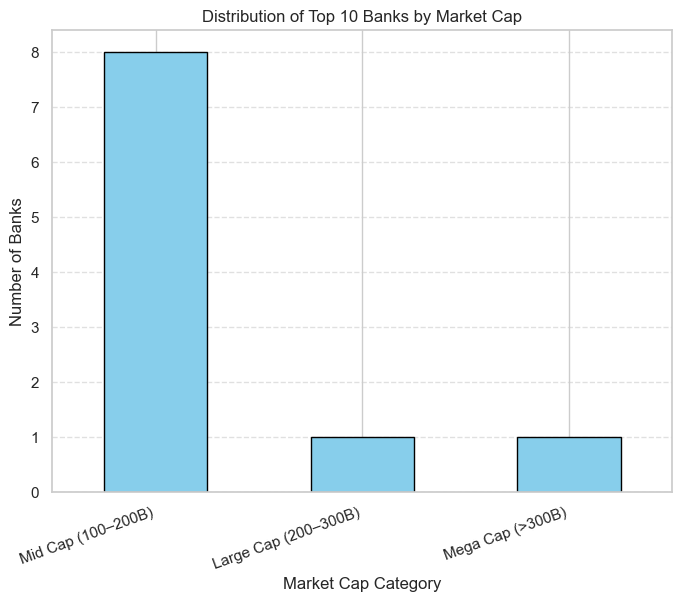

In [27]:
# Market Cap Range Distribution
# Create market cap ranges
bins = [100, 200, 300, 500]  # Market Cap ranges in billions
labels = ["Mid Cap (100–200B)", "Large Cap (200–300B)", "Mega Cap (>300B)"]

pandas_df["CapCategory"] = pd.cut(pandas_df["Market_Cap_USD_Billion"], bins=bins, labels=labels)
category_counts = pandas_df["CapCategory"].value_counts().sort_index()
print(category_counts)
# Plot
plt.figure(figsize=(8,6))
category_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Distribution of Top 10 Banks by Market Cap")
plt.xlabel("Market Cap Category")
plt.ylabel("Number of Banks")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

##**3.9. Visualise Market Share Distribution** <font color = red>[5 Marks]</font> <br>


Calculate and display market share distribution among the top 10 banks using a pie chart.

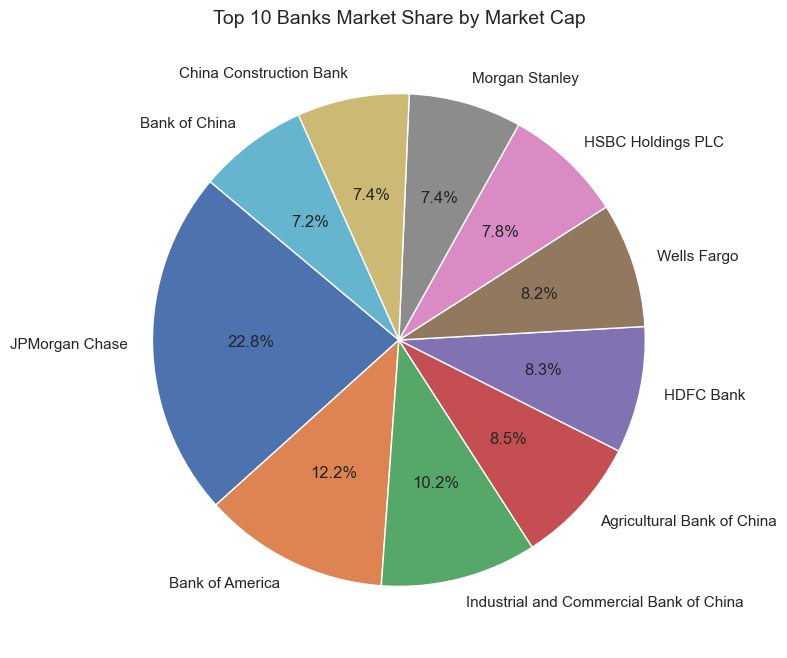

In [28]:
# Top 10 Banks Market Share
# Calculate market share percentage for top 10 banks
pandas_df["market_share"]
# Plot
plt.figure(figsize=(10,8))
plt.pie(
    pandas_df["market_share"],
    labels=pandas_df["Bank_Name"],
    autopct="%.1f%%",   # show % with 1 decimal
    startangle=140,
    wedgeprops={"edgecolor":"white"}
)

plt.title("Top 10 Banks Market Share by Market Cap", fontsize=14)
plt.show()

#**4. ETL and Querying** <font color = red>[45 marks]</font> <br>

In [29]:
#Imports & Spark Session Initialization

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, round
import logging
from datetime import datetime
import sqlite3
import pandas as pd

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("BankingDataAnalysis") \
    .getOrCreate()

# Logging Configuration
logfile = "code_log.txt"

In [30]:
#Logging Function

def log_progress(msg):
    timeformat = '%Y-%h-%d-%H:%M:%S'
    timestamp = datetime.now().strftime(timeformat)
    with open(logfile, 'a') as f:
        f.write(f"{timestamp} : {msg}\n")

In [31]:
# Import required functions
from pyspark.sql.functions import col, avg, sum, count, desc, asc, round, lag, dense_rank, ntile, when, first, lead
from pyspark.sql.window import Window

# First, let's rename your columns to match our queries (if needed)
# we have already renamed the columns ,so need to do that again
# Create window specifications
# Window spec for ranking banks based on market cap.
window_spec = Window.orderBy(col("Market_Cap_USD_Billion").desc())

new_df = df.withColumn("global_rank", dense_rank().over(window_spec))
new_df.show()

+----+--------------------+----------------------+------------------+------------------+------------------+-----------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|global_rank|
+----+--------------------+----------------------+------------------+------------------+------------------+-----------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|          1|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|          2|
|   3|Industrial and Co...|                194.56|180.94080000000002|155.64800000000002|         16138.752|          3|
|   4|Agricultural Bank...|                160.68|          149.4324|           128.544|         13328.406|          4|
|   5|           HDFC Bank|                157.91|          146.8563|           126.328|        13098.6345|          5|
|   6|         Wells Fargo|             

##**4.1. Market Capitalization Analysis** <font color = red>[3 marks]</font> <br                                                                      

Q: Perform Advanced Market Capitalization Analysis with Growth Metrics

In [32]:
# Query: Advanced Market Cap Analysis with Growth Metrics
new_df= new_df.withColumn(
    "next_bank_market_cap",
    lead(col("Market_Cap_USD_Billion"), 1).over(window_spec)
).withColumn(
    "market_cap_growth_metric",
    round(col("Market_Cap_USD_Billion") - col("next_bank_market_cap"),2)
)

new_df.show()

+----+--------------------+----------------------+------------------+------------------+------------------+-----------+--------------------+------------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|global_rank|next_bank_market_cap|market_cap_growth_metric|
+----+--------------------+----------------------+------------------+------------------+------------------+-----------+--------------------+------------------------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|          1|              231.52|                   201.4|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|          2|              194.56|                   36.96|
|   3|Industrial and Co...|                194.56|180.94080000000002|155.64800000000002|         16138.752|          3|              160.68|                   33.88|
|   

##4.2.**Market Concentration Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Market Concentration and Categorize Banks Based on Market Share Tiers

In [33]:
# Market Concentration Analysis
total_market_cap = new_df.agg(sum("Market_Cap_USD_Billion").alias("total")).collect()[0]["total"]
new_df = (
    new_df.withColumn(
        "market_share",
        round(col("Market_Cap_USD_Billion") / total_market_cap * 100, 2)
    )
    .withColumn(
        "market_share_categorized",
        when(col("market_share") > 20, "Tier 1: >20%")
        .when(col("market_share") > 15, "Tier 2: >15%")
        .when(col("market_share") > 10, "Tier 3: >10%")
        .otherwise("Tier 4: <10%")
    )
)

new_df.show()

+----+--------------------+----------------------+------------------+------------------+------------------+-----------+--------------------+------------------------+------------+------------------------+
|Rank|           Bank_Name|Market_Cap_USD_Billion|     MarketCap_EUR|     MarketCap_GBP|     MarketCap_INR|global_rank|next_bank_market_cap|market_cap_growth_metric|market_share|market_share_categorized|
+----+--------------------+----------------------+------------------+------------------+------------------+-----------+--------------------+------------------------+------------+------------------------+
|   1|      JPMorgan Chase|                432.92|402.61560000000003|           346.336|         35910.714|          1|              231.52|                   201.4|       22.79|            Tier 1: >20%|
|   2|     Bank of America|                231.52|          215.3136|           185.216|19204.584000000003|          2|              194.56|                   36.96|       12.19|      

##**4.3. Market Capitalization Distribution** <font color = red>[6 marks]</font> <br>

Q: Examine Statistical Distribution of Market Capitalization Using Quartile Analysis

In [ ]:
# Import required functions
from pyspark.sql.functions import (col, avg, sum, count, desc, asc, round, lag,
                                 dense_rank, ntile, when, first, lead, min, max, lit)
from pyspark.sql.window import Window

# Query 3: Statistical Distribution Analysis
window_spec = Window.orderBy(col("Market_Cap_USD_Billion").desc())

new_df = new_df.withColumn("Quartiles",ntile(4).over(window_spec))
new_df.show()



##**4.4. Comparative Size Analysis** <font color = red>[6 marks]</font> <br>

Q: Conduct Comparative Size Analysis to Classify Banks by Relative Market Size

In [ ]:
# Comparative Size Analysis
new_df = (new_df.withColumn("Market_size_quartile",ntile(4).over(window_spec))
                    .withColumn("size_category",
                    when(col("Market_size_quartile")==1, "Large cap.").
                    when(col("Market_size_quartile")==2, "medium cap.").
                    when(col("Market_size_quartile")==3, "Small cap.").
                    otherwise("Micro cap.")
                               )
                   )
new_df.show()


##**4.5. Market Growth Analysis** <font color = red>[6 marks]</font> <br>

Q: Evaluate Market Growth and Identify Gaps Between Consecutive Banks

In [ ]:
# Growth and Gap Analysis
new_df= (new_df.withColumn("Previous_market_cap",lag("Market_Cap_USD_Billion").over(window_spec))
          .withColumn("gap_btw_conse_baanks",
            round(col("Previous_market_cap") - col("Market_Cap_USD_Billion") ,2)
                     )
         )
new_df.show()

##**4.6. Market Dominance Analysis** <font color = red>[6 marks]</font> <br>

Q: Assess Market Dominance by Measuring Cumulative Share and Dominance Score

In [ ]:
# Market Dominance Analysis
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Compute total market cap
total_market_cap = new_df.agg(F.sum("Market_Cap_USD_Billion")).collect()[0][0]

# 2. Add market_share column
new_df = new_df.withColumn(
    "market_share",
    (F.col("Market_Cap_USD_Billion") / F.lit(total_market_cap)) * 100
)

# 3. Define window for cumulative sum
w = (
    Window
    .orderBy(F.col("Market_Cap_USD_Billion").desc())
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

# 4. Add cumulative market share and dominance score
new_df = (
    new_df
    .withColumn("cum_market_share", F.sum("market_share").over(w))
    .withColumn("dominance_score", F.round(F.col("market_share") / F.col("Rank"), 2))
)

new_df.show()


##**4.7. Segment-Wise Bank Analysis** <font color = red>[6 marks]</font> <br>

Q: Analyze Segment-Wise Bank Performance Based on Market Capitalization Ranges

In [ ]:
# Segment Performance Analysis
new_df = new_df.withColumn(
    "market_segment",
    when(col("Market_Cap_USD_Billion") >= 200, "Large Cap")
    .when(col("Market_Cap_USD_Billion") >= 150, "Mid Cap")
    .otherwise("Small Cap")
)

# Group by the new market segment and sum the market cap
grouped_df = new_df.groupBy("market_segment") \
                                     .agg(sum("Market_Cap_USD_Billion").alias("total_market_cap")) \
                                     .orderBy(col("total_market_cap").desc())
grouped_df.show()

##**4.8. Performance Dashboard** <font color = red>[6 marks]</font> <br>

Q: Generate a Comprehensive Performance Dashboard for Bank Rankings and Metrics

In [ ]:
# To Generate a Comprehensive Performance Dashboard we have to convert the current df into pandas dataframe
data = new_df.toPandas()
data.head()

In [ ]:
# Comprehensive Performance Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top Banks by Market Cap (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='Market_Cap_USD_Billion', y='Bank_Name',
            data=data.sort_values('Market_Cap_USD_Billion', ascending=False))
plt.title("Top Banks by Market Capitalization (USD Billion)")
plt.xlabel("Market Cap (USD Billion)")
plt.ylabel("Bank Name")
plt.tight_layout()
plt.show()

# 2. Market Share Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(data['market_share'], labels=data['Bank_Name'],
        autopct='%1.1f%%', startangle=140)
plt.title("Market Share Distribution of Banks")
plt.axis('equal')
plt.show()

# 3. Market Share Categories (Count Plot)
plt.figure(figsize=(8, 5))
sns.countplot(x='market_share_categorized', data=data,
              order=data['market_share_categorized'].value_counts().index)
plt.title("Count of Banks by Market Share Category")
plt.xlabel("Market Share Category")
plt.ylabel("Number of Banks")
plt.tight_layout()
plt.show()

# 4. Quartile vs Market Cap (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Quartiles', y='Market_Cap_USD_Billion', data=data)
plt.title("Market Cap Distribution by Quartile")
plt.xlabel("Quartile")
plt.ylabel("Market Cap (USD Billion)")
plt.tight_layout()
plt.show()

# 5. Market Size Segments (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Market_size_quartile',
    y='Market_Cap_USD_Billion',
    data=data,
    estimator=lambda x: x.sum()
)

plt.title("Total Market Cap by Size Category")
plt.xlabel("Size Category")
plt.ylabel("Total Market Cap (USD Billion)")
plt.tight_layout()
plt.show()

# 6. Gap Between Consecutive Banks (Line Chart)
plt.figure(figsize=(10, 5))
sns.lineplot(x='Rank', y='gap_btw_conse_baanks', data=data, marker='o')
plt.title("Gap in Market Cap Between Consecutive Banks")
plt.xlabel("Bank Rank")
plt.ylabel("Gap (USD Billion)")
plt.tight_layout()
plt.show()

# 7. Cumulative Market Share (Line Chart)
plt.figure(figsize=(10, 5))
sns.lineplot(x='Rank', y='cum_market_share', data=data, marker='o')
plt.title("Cumulative Market Share by Rank")
plt.xlabel("Bank Rank")
plt.ylabel("Cumulative Market Share (%)")
plt.tight_layout()
plt.show()

# 8. Dominance Score (Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='dominance_score', y='Bank_Name',
            data=data.sort_values('dominance_score', ascending=False))
plt.title("Dominance Score of Banks")
plt.xlabel("Dominance Score")
plt.ylabel("Bank Name")
plt.tight_layout()
plt.show()


#5. Visualization Integration

In [ ]:
#  Prepare data for visualization platforms
# Save PySpark DF to CSV
new_df.toPandas().to_csv("banks_market_cap.csv", index=False)

In [ ]:
# Visualization Setup Section

# 1. Prepare data for visualization platforms
#    - Save the pandas DataFrame as a clean CSV or database table
#  new_df.toPandas().to_csv("banks_market_cap.csv", index=False)

# 1A. Upload the CSV to AWS S3 (for centralized access)
# Make sure AWS credentials are configured (via AWS CLI or environment variables))



# 2. Generate Tableau connection instructions
# tableau_instructions = f"""
# Tableau Connection Steps:
# 1. Open Tableau Desktop.
# 2. Click on 'Connect' → 'Amazon S3'.
# 3. Enter your AWS credentials and select the bucket '{bucket_name}'.
# 4. Locate and select '{object_name}'.
# 5. Drag the dataset into the workspace.
# 6. Use 'Market_Cap_USD_Billion', 'Rank', 'market_share', etc., for visualizations.
# """



# 3. Generate Power BI connection instructions
# powerbi_instructions = f"""
# Power BI Connection Steps:
# 1. Open Power BI Desktop.
# 2. Click 'Get Data' → 'Amazon S3'.
# 3. Enter AWS credentials and connect to the bucket '{bucket_name}'.
# 4. Load '{object_name}' into Power BI.
# 5. Use the available fields to create visuals like:
#    - Top N Banks by Market Cap (Bar Chart)
#    - Market Share Distribution (Pie or Donut Chart)
#    - Cumulative Market Share (Line Chart)
# """

# 4. Execute visualization setup
# we will do ,all these above steps in power bi to connect it with aws s3 bucket and then do some visualizations on that data.


# 5. Sample Dashboard Layout (Documentation)


# 5. Sample Dashboard Layout (Documentation)
This documentation provides an overview of the data analysis performed on the provided dataset of the top 10 global banks by market capitalization.

1. Analysis Objective
The primary objective of this analysis is to explore and understand the market capitalization landscape of the world's top banks. The goal is to identify key trends, rankings, and the concentration of market power within the financial industry using the provided dataset.

2. Data Description
The dataset contains information on 10 banks, with the following key fields:

Rank: The bank's position based on market capitalization.

Bank name: The name of the financial institution.

Market cap (US$ billion): The total market value of the bank's outstanding shares, measured in billions of US dollars.

3. Key Findings and Insights
Based on the suggested visualizations, the following insights can be derived from the data:

JPMorgan Chase Dominance: The bar chart clearly shows that JPMorgan Chase holds a significantly higher market capitalization ($432.92 billion) than its peers, reinforcing its position as the top-ranked bank.

Market Share Concentration: The pie or donut chart would reveal that the top two banks, JPMorgan Chase and Bank of America, account for a substantial portion of the total market share among the top 10. This indicates a high concentration of market power at the very top.

Rapid Decline in Market Cap: The scatter plot of rank versus market capitalization illustrates a steep, inverse relationship. As the rank decreases (e.g., from rank 1 to 2, then to 3), the market capitalization drops significantly, but the decline becomes more gradual for the lower-ranked banks.

Top 3 Holding Over 50% of the Market: The line chart showing cumulative market share would highlight that the top three banks—JPMorgan Chase, Bank of America, and the Industrial and Commercial Bank of China—collectively account for more than 50% of the total market capitalization of the top 10.

4. Conclusion
The analysis of this dataset reveals a highly concentrated market where the top-ranked banks, particularly JPMorgan Chase, hold a disproportionately large share of the total market capitalization. The visualizations provide a clear, intuitive way to understand these market dynamics and the competitive landscape among the world's leading financial institutions. The insights gained from this analysis can be valuable for stakeholders to assess market positioning and trends.